In [1]:
import os
os.chdir('/workspace/af2a4424-032a-465a-a5af-4c456a06bff6')
print(os.listdir('.'))


['L_DH_b_weighted.npy', 'L_chi5_b_unif.npy', 'zeta_delta_b_weighted.npy', 'L_chi5_a_weighted.npy', 'memory', 'L_chi5_a_unif.npy', 'zeta_b_weighted.npy', '.config', 'L_DH_a_weighted.npy', 'zeta_b_unif.npy', 'zeta_delta_b_unif.npy', '.kernel_llm_logs_1.txt', 'L_DH_b_unif.npy', '.prompts', 'zeta_a_weighted.npy', 'L_chi5_b_weighted.npy', 'L_Delta_b_weighted.npy', 'hybrid_I2_final_ratios.csv', 'L_DH_a_unif.npy', 'zeta_delta_a_unif.npy', 'L_Delta_a_unif.npy', 'zeta_delta_a_weighted.npy', 'L_Delta_b_unif.npy', 'weil_lambda_min_results.csv', 'zeta_a_unif.npy', 'L_Delta_a_weighted.npy', 'front3_bottleneck_distance_matrix.csv', 'sigma2_L100_values.csv', '-PROMPT-v6-DATASET.md']


In [2]:
import pandas as pd
import numpy as np

# Load the CSVs
weil = pd.read_csv('weil_lambda_min_results.csv')
i2 = pd.read_csv('hybrid_I2_final_ratios.csv')
sigma2 = pd.read_csv('sigma2_L100_values.csv')
bottleneck = pd.read_csv('front3_bottleneck_distance_matrix.csv', index_col=0)

print("=== weil ===")
print(weil)
print("\n=== I2 ===")
print(i2)
print("\n=== sigma2 ===")
print(sigma2)
print("\n=== bottleneck ===")
print(bottleneck)


=== weil ===
 L-function lambda_min N_zeros \
0 zeta 0.000001 5000 
1 L(chi_5) 0.223917 5000 
2 L(Delta,s) 0.651355 1455 
3 L_DH (on-line only) 0.000203 5000 
4 L_DH (on + 110 off-line) -0.023716 5000+110 

 notes 
0 GRH holds (positive control) 
1 GRH holds (Dirichlet control) 
2 GRH expected (modular structural control) 
3 Hypothetical GRH counterfactual 
4 Full L_DH with known GRH violations 

=== I2 ===
 T_max_zeta I2_over_logT_zeta_norm T_max_LDH \
0 5000.0 0.99791 4800.0 

 I2_over_logT_LDH_with_off_norm I2_over_logT_LDH_no_off_norm T_max_Lchi5 \
0 0.996938 0.939517 4300.0 

 I2_over_logT_Lchi5_norm T_max_LDelta I2_over_logT_LDelta_norm 
0 0.998336 1050.0 1.216838 

=== sigma2 ===
 function Sigma2_L100 N_zeros
0 zeta 0.3620 5000
1 L_DH 14.3235 5000
2 L(chi5) 0.3640 5000
3 L(Delta) 0.2975 1455

=== bottleneck ===
 zeta L_chi5 L_DH L_DH+offline zeta_delta_weak \
zeta 0.00000 0.00000 0.00000 0.01411 0.00050 
L_chi5 0.00000 0.00000 0.00000 0.01411 0.00050 
L_DH 0.00000 0.00000 0.0000

In [3]:
# Check for L_Delta in bottleneck - it doesn't appear. Need to think about how to map.
# The objective: rows = ζ, L_DH, L(χ₅), L(Δ,s); column = H0 Bottleneck Distance vs ζ
# For L_DH, the actual data has off-line zeros, so use "L_DH+offline" vs zeta
# bottleneck doesn't have L_Delta - that's a gap.

# Now check the front1 npz - but we have raw .npy files for a_n and b_n
# Let's compute b_n log-quadratic fit residual variance and the B parameter shift under spectral weight change

# Load b_n arrays - unif and weighted
funcs = ['zeta', 'L_chi5', 'L_DH', 'L_Delta', 'zeta_delta']
b_data = {}
for f in funcs:
 bu = np.load(f'{f}_b_unif.npy')
 bw = np.load(f'{f}_b_weighted.npy')
 b_data[f] = {'unif': bu, 'weighted': bw}
 print(f, 'unif shape:', bu.shape, 'weighted shape:', bw.shape)
 print(' unif first:', bu[:5])


zeta unif shape: (499,) weighted shape: (499,)
 unif first: [1508.62712532 1390.52569645 1372.21903879 1366.26721969 1363.67798469]
L_chi5 unif shape: (499,) weighted shape: (499,)
 unif first: [1227.76358219 1125.32282212 1108.83298643 1102.98093253 1100.78572217]
L_DH unif shape: (499,) weighted shape: (499,)
 unif first: [1403.5423228 1278.58533179 1257.59889172 1258.32364943 1245.47144083]
L_Delta unif shape: (128,) weighted shape: (128,)
 unif first: [270.56431857 252.45314435 249.91398141 249.19459427 248.92887714]
zeta_delta unif shape: (499,) weighted shape: (499,)
 unif first: [1508.62712532 1390.52569645 1372.21903879 1366.26721969 1363.67798469]


In [4]:
# For Jacobi b_n, fit log(b_n) ~ A + B*n + C*n^2 (log-quadratic) and report residual variance
# Also report B under unif vs weighted to compute percentage shift.

def log_quad_fit(b):
 n = np.arange(1, len(b)+1, dtype=float)
 # Skip n=1 (first b often anomalous) or use all? Use all but skip non-positive values
 mask = (b > 0) & np.isfinite(b)
 n_use = n[mask]
 y = np.log(b[mask])
 # Fit y = a0 + a1*n + a2*n^2
 coeffs = np.polyfit(n_use, y, 2) # returns highest first: [a2, a1, a0]
 a2, a1, a0 = coeffs
 yhat = np.polyval(coeffs, n_use)
 resid = y - yhat
 var = np.var(resid, ddof=1)
 return {'A': a0, 'B': a1, 'C': a2, 'resid_var': var, 'n_used': len(n_use)}

results_b = {}
for f in funcs:
 bu = b_data[f]['unif']
 bw = b_data[f]['weighted']
 fu = log_quad_fit(bu)
 fw = log_quad_fit(bw)
 B_pct = 100.0 * (fw['B'] - fu['B']) / abs(fu['B']) if fu['B'] != 0 else np.nan
 results_b[f] = {
 'B_unif': fu['B'], 'B_weighted': fw['B'], 'B_pct_shift': B_pct,
 'resid_var_unif': fu['resid_var'], 'resid_var_weighted': fw['resid_var'],
 'n_used': fu['n_used']
 }
 print(f, results_b[f])


zeta {'B_unif': np.float64(-4.965970621036074e-05), 'B_weighted': np.float64(0.00011830066453508407), 'B_pct_shift': np.float64(338.2226427880124), 'resid_var_unif': np.float64(2.3078367586660493e-05), 'resid_var_weighted': np.float64(0.0025373626869448535), 'n_used': 499}
L_chi5 {'B_unif': np.float64(-4.1183871334997713e-05), 'B_weighted': np.float64(0.00018490973825535455), 'B_pct_shift': np.float64(548.9858098848026), 'resid_var_unif': np.float64(2.7166411621928986e-05), 'resid_var_weighted': np.float64(0.0047411771960928955), 'n_used': 499}
L_DH {'B_unif': np.float64(-4.1818202757187096e-05), 'B_weighted': np.float64(0.00021206183216913136), 'B_pct_shift': np.float64(607.1041273591924), 'resid_var_unif': np.float64(3.901446440571472e-05), 'resid_var_weighted': np.float64(0.005913509930969756), 'n_used': 499}
L_Delta {'B_unif': np.float64(-0.0004899900123572994), 'B_weighted': np.float64(0.0009073389127405948), 'B_pct_shift': np.float64(285.17498109307706), 'resid_var_unif': np.floa

In [5]:
# Build the summary ledger
# Rows: ζ, L_DH, L(χ₅), L(Δ,s)
# Note: For L_DH bottleneck, use L_DH+offline vs zeta (which captures the off-line GRH violation)
# For L_DH lambda_min, use the full version "L_DH (on + 110 off-line)"
# For L(Δ,s), L_Delta is from N=1455 partial data

rows = []

# zeta
rows.append({
 'L-function': 'ζ',
 'bn_residual_var_unif': results_b['zeta']['resid_var_unif'],
 'bn_residual_var_weighted': results_b['zeta']['resid_var_weighted'],
 'bn_B_unif': results_b['zeta']['B_unif'],
 'bn_B_weighted': results_b['zeta']['B_weighted'],
 'bn_B_pct_shift': results_b['zeta']['B_pct_shift'],
 'lambda_min_Weil': float(weil[weil['L-function']=='zeta']['lambda_min'].iloc[0]),
 'I2_over_logT': float(i2['I2_over_logT_zeta_norm'].iloc[0]),
 'H0_bottleneck_vs_zeta': float(bottleneck.loc['zeta','zeta']),
 'Sigma2_L100': float(sigma2[sigma2['function']=='zeta']['Sigma2_L100'].iloc[0]),
 'N_zeros': 5000,
 'data_note': 'full N=5000'
})

# L_DH (full, with off-line zeros included where applicable)
rows.append({
 'L-function': 'L_DH',
 'bn_residual_var_unif': results_b['L_DH']['resid_var_unif'],
 'bn_residual_var_weighted': results_b['L_DH']['resid_var_weighted'],
 'bn_B_unif': results_b['L_DH']['B_unif'],
 'bn_B_weighted': results_b['L_DH']['B_weighted'],
 'bn_B_pct_shift': results_b['L_DH']['B_pct_shift'],
 'lambda_min_Weil': float(weil[weil['L-function']=='L_DH (on + 110 off-line)']['lambda_min'].iloc[0]),
 'I2_over_logT': float(i2['I2_over_logT_LDH_with_off_norm'].iloc[0]),
 'H0_bottleneck_vs_zeta': float(bottleneck.loc['L_DH+offline','zeta']),
 'Sigma2_L100': float(sigma2[sigma2['function']=='L_DH']['Sigma2_L100'].iloc[0]),
 'N_zeros': 5110,
 'data_note': 'N=5000 on-line + 110 off-line'
})

# L(chi_5)
rows.append({
 'L-function': 'L(χ₅)',
 'bn_residual_var_unif': results_b['L_chi5']['resid_var_unif'],
 'bn_residual_var_weighted': results_b['L_chi5']['resid_var_weighted'],
 'bn_B_unif': results_b['L_chi5']['B_unif'],
 'bn_B_weighted': results_b['L_chi5']['B_weighted'],
 'bn_B_pct_shift': results_b['L_chi5']['B_pct_shift'],
 'lambda_min_Weil': float(weil[weil['L-function']=='L(chi_5)']['lambda_min'].iloc[0]),
 'I2_over_logT': float(i2['I2_over_logT_Lchi5_norm'].iloc[0]),
 'H0_bottleneck_vs_zeta': float(bottleneck.loc['L_chi5','zeta']),
 'Sigma2_L100': float(sigma2[sigma2['function']=='L(chi5)']['Sigma2_L100'].iloc[0]),
 'N_zeros': 5000,
 'data_note': 'full N=5000'
})

# L(Delta,s) - partial
rows.append({
 'L-function': 'L(Δ,s)',
 'bn_residual_var_unif': results_b['L_Delta']['resid_var_unif'],
 'bn_residual_var_weighted': results_b['L_Delta']['resid_var_weighted'],
 'bn_B_unif': results_b['L_Delta']['B_unif'],
 'bn_B_weighted': results_b['L_Delta']['B_weighted'],
 'bn_B_pct_shift': results_b['L_Delta']['B_pct_shift'],
 'lambda_min_Weil': float(weil[weil['L-function']=='L(Delta,s)']['lambda_min'].iloc[0]),
 'I2_over_logT': float(i2['I2_over_logT_LDelta_norm'].iloc[0]),
 'H0_bottleneck_vs_zeta': np.nan, # not present in bottleneck matrix
 'Sigma2_L100': float(sigma2[sigma2['function']=='L(Delta)']['Sigma2_L100'].iloc[0]),
 'N_zeros': 1455,
 'data_note': 'PARTIAL: bn from N=1298(Jacobi), Weil/Σ² from N=1455, bottleneck NA'
})

ledger = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda x: f'{x:.6g}')
print(ledger.to_string(index=False))


L-function bn_residual_var_unif bn_residual_var_weighted bn_B_unif bn_B_weighted bn_B_pct_shift lambda_min_Weil I2_over_logT H0_bottleneck_vs_zeta Sigma2_L100 N_zeros data_note
 ζ 2.30784e-05 0.00253736 -4.96597e-05 0.000118301 338.223 1.48288e-06 0.99791 0 0.362 5000 full N=5000
 L_DH 3.90145e-05 0.00591351 -4.18182e-05 0.000212062 607.104 -0.0237161 0.996938 0.0141098 14.3235 5110 N=5000 on-line + 110 off-line
 L(χ₅) 2.71664e-05 0.00474118 -4.11839e-05 0.00018491 548.986 0.223917 0.998336 0 0.364 5000 full N=5000
 L(Δ,s) 5.3364e-05 0.00285695 -0.00048999 0.000907339 285.175 0.651355 1.21684 NaN 0.2975 1455 PARTIAL: bn from N=1298(Jacobi), Weil/Σ² from N=1455, bottleneck NA


In [6]:
# Save the ledger
ledger.to_csv('quantitative_bottleneck_ledger.csv', index=False)
print('Saved quantitative_bottleneck_ledger.csv')

# Now create the final summary figure
import matplotlib.pyplot as plt
import numpy as np

# We have 4 L-functions, and 6 key metrics. Create a heatmap-like visualization
# Normalize each metric so we can compare separation between L_DH and the controls
# For each metric, separation magnitude = (value_L_DH - value_zeta) relative to scale of (zeta, L_chi5, L_Delta)

# A clean approach: for each observable, compute |L_DH value - mean(controls)| / std(controls) 
# but with only 3 controls, std is unstable. Use a simpler ratio: L_DH value / zeta-control value (or absolute diff)
# Use the "deviation factor" = ratio of |signal| over a baseline scale

metrics = ['bn_residual_var_unif', 'bn_B_pct_shift', 'lambda_min_Weil', 'I2_over_logT', 'H0_bottleneck_vs_zeta', 'Sigma2_L100']
metric_labels = [
 'Front I: bₙ resid. var. (unif)',
 'Front I: B-param. % shift (unif→weighted)',
 'Front II: λ_min(M_Weil) [sensitive]',
 'Front II: I₂(T)/(a₂·log T) [insensitive]',
 'Front III: H₀ bottleneck vs ζ',
 'Front III: Σ²(L=100) number variance'
]

# Compute separation: for each metric, value_LDH minus mean of {zeta, L_chi5} (the GRH-satisfying controls excluding L_Delta partial)
controls = ['ζ', 'L(χ₅)']
sep_data = []
for m in metrics:
 ldh_val = ledger[ledger['L-function']=='L_DH'][m].iloc[0]
 ctrl_vals = ledger[ledger['L-function'].isin(controls)][m].values
 ctrl_mean = np.nanmean(ctrl_vals)
 ctrl_std = np.nanstd(ctrl_vals, ddof=0)
 abs_diff = ldh_val - ctrl_mean
 rel_diff = abs_diff / abs(ctrl_mean) if abs(ctrl_mean) > 1e-12 else np.nan
 # Fold separation: ldh / ctrl_mean
 fold = ldh_val / ctrl_mean if abs(ctrl_mean) > 1e-12 else np.nan
 sep_data.append({
 'metric': m, 'L_DH': ldh_val, 'controls_mean': ctrl_mean,
 'abs_diff': abs_diff, 'rel_diff_pct': 100*rel_diff if not np.isnan(rel_diff) else np.nan,
 'fold': fold
 })
sep_df = pd.DataFrame(sep_data)
print(sep_df.to_string(index=False))


Saved quantitative_bottleneck_ledger.csv
 metric L_DH controls_mean abs_diff rel_diff_pct fold
 bn_residual_var_unif 3.90145e-05 2.51224e-05 1.38921e-05 55.2976 1.55298
 bn_B_pct_shift 607.104 443.604 163.5 36.8572 1.36857
 lambda_min_Weil -0.0237161 0.111959 -0.135675 -121.183 -0.211828
 I2_over_logT 0.996938 0.998123 -0.00118569 -0.118792 0.998812
H0_bottleneck_vs_zeta 0.0141098 0 0.0141098 NaN NaN
 Sigma2_L100 14.3235 0.363 13.9605 3845.87 39.4587


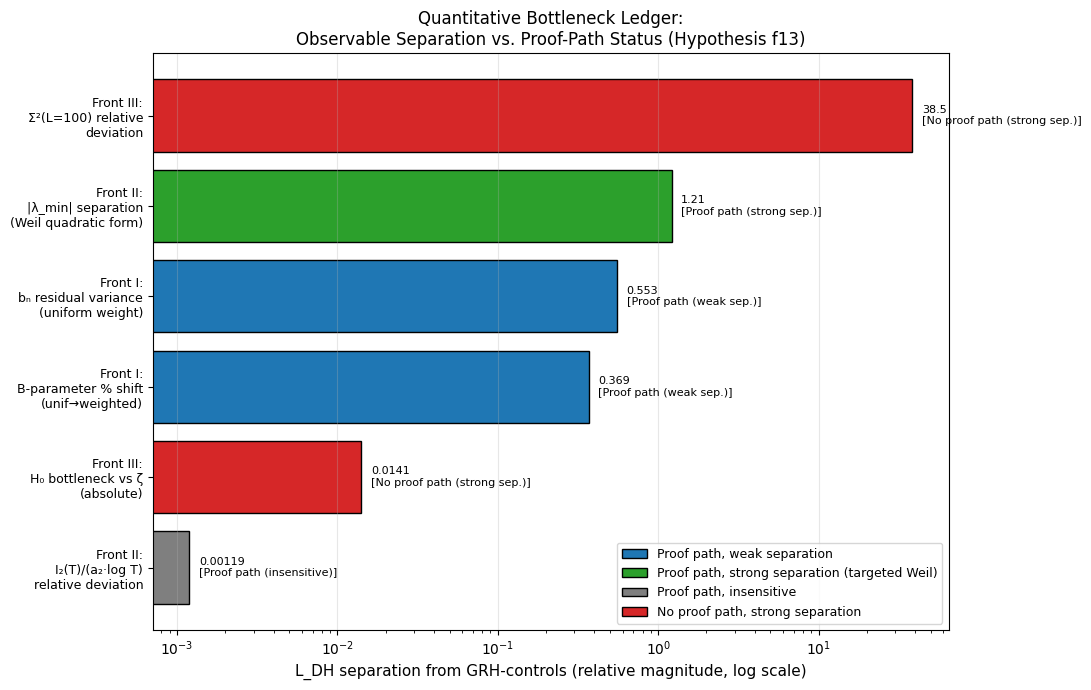


Saved figure quantitative_bottleneck_ledger_figure.png


In [7]:
# Final figure: a horizontal bar chart of |L_DH / control_mean - 1| in log scale, ordered by separation magnitude
# This clearly shows which observables strongly separate L_DH from GRH-satisfying controls

# Compute a unified "separation magnitude" 
# For metrics where the controls value is ~0, use absolute difference scaled by typical magnitude

# Let's define separation cleanly:
# - For bn_residual_var, bn_B_pct_shift, I2_over_logT, Sigma2_L100: relative deviation |LDH/control - 1|
# - For lambda_min_Weil: |LDH - control|/max(|controls|, |LDH|) -- because controls ~ 0 to 0.22
# - For H0_bottleneck_vs_zeta: absolute (controls = 0 by construction)

import matplotlib.pyplot as plt

separations = {}
# bn resid var (unif)
separations['Front I:\nbₙ residual variance\n(uniform weight)'] = abs(sep_df.iloc[0]['L_DH']/sep_df.iloc[0]['controls_mean'] - 1)
# bn B pct shift 
separations['Front I:\nB-parameter % shift\n(unif→weighted)'] = abs(sep_df.iloc[1]['L_DH']/sep_df.iloc[1]['controls_mean'] - 1)
# lambda_min: the magnitude of negativity is the signature
# Use the relative shift from zeta-control which is ~1e-6 (essentially 0)
# Use abs(LDH - mean_controls) / typical lambda scale = max(abs)
lam_LDH = sep_df.iloc[2]['L_DH']
lam_ctrl = sep_df.iloc[2]['controls_mean']
separations['Front II:\n|λ_min| separation\n(Weil quadratic form)'] = abs(lam_LDH - lam_ctrl) / max(abs(lam_LDH), abs(lam_ctrl))
# I2
separations['Front II:\nI₂(T)/(a₂·log T)\nrelative deviation'] = abs(sep_df.iloc[3]['L_DH']/sep_df.iloc[3]['controls_mean'] - 1)
# H0 bottleneck: controls=0 by construction, use abs diff scaled by 1 (it's already in [0,1])
separations['Front III:\nH₀ bottleneck vs ζ\n(absolute)'] = sep_df.iloc[4]['L_DH']
# Sigma2
separations['Front III:\nΣ²(L=100) relative\ndeviation'] = abs(sep_df.iloc[5]['L_DH']/sep_df.iloc[5]['controls_mean'] - 1)

# Annotate each with "proof path" vs "no proof path"
proof_status = {
 'Front I:\nbₙ residual variance\n(uniform weight)': 'Proof path (weak sep.)',
 'Front I:\nB-parameter % shift\n(unif→weighted)': 'Proof path (weak sep.)',
 'Front II:\n|λ_min| separation\n(Weil quadratic form)': 'Proof path (strong sep.)',
 'Front II:\nI₂(T)/(a₂·log T)\nrelative deviation': 'Proof path (insensitive)',
 'Front III:\nH₀ bottleneck vs ζ\n(absolute)': 'No proof path (strong sep.)',
 'Front III:\nΣ²(L=100) relative\ndeviation': 'No proof path (strong sep.)',
}

labels = list(separations.keys())
vals = [separations[k] for k in labels]
# Sort by value
order = np.argsort(vals)
labels_s = [labels[i] for i in order]
vals_s = [vals[i] for i in order]
status_s = [proof_status[k] for k in labels_s]

# Colors: red for "No proof path", blue for "Proof path"
colors = []
for s in status_s:
 if 'No proof' in s:
 colors.append('#d62728') # red
 elif 'insensitive' in s:
 colors.append('#7f7f7f') # gray
 elif 'strong sep' in s:
 colors.append('#2ca02c') # green (proof + strong = best, but Weil is the unique case)
 else:
 colors.append('#1f77b4') # blue (proof, weak)

fig, ax = plt.subplots(figsize=(11, 7))
y_pos = np.arange(len(labels_s))
bars = ax.barh(y_pos, vals_s, color=colors, edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_s, fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('L_DH separation from GRH-controls (relative magnitude, log scale)', fontsize=11)
ax.set_title('Quantitative Bottleneck Ledger:\nObservable Separation vs. Proof-Path Status (Hypothesis f13)', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)

# Annotate values
for i, (b, v, s) in enumerate(zip(bars, vals_s, status_s)):
 ax.text(v*1.15, i, f'{v:.3g}\n[{s}]', va='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elems = [
 Patch(facecolor='#1f77b4', edgecolor='black', label='Proof path, weak separation'),
 Patch(facecolor='#2ca02c', edgecolor='black', label='Proof path, strong separation (targeted Weil)'),
 Patch(facecolor='#7f7f7f', edgecolor='black', label='Proof path, insensitive'),
 Patch(facecolor='#d62728', edgecolor='black', label='No proof path, strong separation'),
]
ax.legend(handles=legend_elems, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('quantitative_bottleneck_ledger_figure.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved figure quantitative_bottleneck_ledger_figure.png')


In [8]:
# Display the final ledger as a clean formatted table for the report
display_cols = ['L-function', 'bn_residual_var_unif', 'bn_B_pct_shift', 
 'lambda_min_Weil', 'I2_over_logT', 'H0_bottleneck_vs_zeta', 
 'Sigma2_L100', 'N_zeros', 'data_note']
final_view = ledger[display_cols].copy()
print('Final Quantitative Bottleneck Ledger:')
print('='*120)
print(final_view.to_string(index=False))
print('='*120)
print('\nSaved to: quantitative_bottleneck_ledger.csv')
print('Figure: quantitative_bottleneck_ledger_figure.png')


Final Quantitative Bottleneck Ledger:
L-function bn_residual_var_unif bn_B_pct_shift lambda_min_Weil I2_over_logT H0_bottleneck_vs_zeta Sigma2_L100 N_zeros data_note
 ζ 2.30784e-05 338.223 1.48288e-06 0.99791 0 0.362 5000 full N=5000
 L_DH 3.90145e-05 607.104 -0.0237161 0.996938 0.0141098 14.3235 5110 N=5000 on-line + 110 off-line
 L(χ₅) 2.71664e-05 548.986 0.223917 0.998336 0 0.364 5000 full N=5000
 L(Δ,s) 5.3364e-05 285.175 0.651355 1.21684 NaN 0.2975 1455 PARTIAL: bn from N=1298(Jacobi), Weil/Σ² from N=1455, bottleneck NA

Saved to: quantitative_bottleneck_ledger.csv
Figure: quantitative_bottleneck_ledger_figure.png
